# Project 23 — Depth-First Search: Open-Source Dependency Explorer

**Goal:** use DFS for real code-dependency reachability, change-impact analysis and cycle detection.

The notebook parses the installed open-source **requests 2.32.5** package with Python AST, builds a directed module-dependency graph, implements DFS from scratch and prints/visualises the results.

**Big-company connection:** dependency reachability is relevant to GitHub/GitLab code intelligence, CI/CD build impact and software-security tools.


In [1]:
from pathlib import Path
import ast, time, requests, numpy as np, pandas as pd, networkx as nx, matplotlib.pyplot as plt

package_dir = Path(requests.__file__).resolve().parent
py_files = sorted(package_dir.glob("*.py"))
module_names = {p.stem if p.stem != "__init__" else "__init__" for p in py_files}
DG = nx.DiGraph(); DG.add_nodes_from(module_names)

for path in py_files:
    tree = ast.parse(path.read_text(encoding="utf-8"))
    current = path.stem if path.stem != "__init__" else "__init__"
    for node in ast.walk(tree):
        if isinstance(node, ast.ImportFrom):
            if node.module and node.module.startswith("requests."):
                target = node.module.split(".")[1]
                if target in module_names: DG.add_edge(current,target)
            elif node.level and node.module:
                target = node.module.split(".")[0]
                if target in module_names: DG.add_edge(current,target)

print(f"Real package analysed: requests {requests.__version__}")
print(f"Python modules: {DG.number_of_nodes()}")
print(f"Internal dependency edges: {DG.number_of_edges()}")


Real package analysed: requests 2.32.5
Python modules: 18
Internal dependency edges: 55

In [2]:
def dfs(graph,start):
    visited=set(); order=[]; stack=[start]
    while stack:
        node=stack.pop()
        if node in visited: continue
        visited.add(node); order.append(node)
        stack.extend(n for n in sorted(graph.successors(node),reverse=True) if n not in visited)
    return order

order = dfs(DG,"__init__")
print(f"DFS reached {len(order)} of {DG.number_of_nodes()} modules.")
print("Traversal order:")
print(" -> ".join(order))


DFS reached 17 of 18 modules.
Traversal order:
__init__ -> __version__ -> api -> sessions -> _internal_utils -> compat -> adapters -> auth -> cookies -> utils -> certs -> exceptions -> structures -> models -> hooks -> status_codes -> packages

In [3]:
target_module="models"
reverse_graph=DG.reverse(copy=True)
impacted=dfs(reverse_graph,target_module)
impact_df=pd.DataFrame({
    "impacted_module":impacted,
    "directly_depends_on_target":[DG.has_edge(m,target_module) for m in impacted]
})
print(f"Changing {target_module}.py can potentially affect {len(impacted)} modules including itself.")
display(impact_df)


Changing models.py can potentially affect 5 modules including itself.


  impacted_module  directly_depends_on_target
0          models                       False
1        __init__                        True
2        adapters                        True
3        sessions                        True
4             api                       False

In [4]:
def find_cycles_dfs(graph):
    WHITE,GRAY,BLACK=0,1,2
    state={n:WHITE for n in graph}; parent={}; cycles=[]
    def visit(u):
        state[u]=GRAY
        for v in graph.successors(u):
            if state[v]==WHITE:
                parent[v]=u; visit(v)
            elif state[v]==GRAY:
                cycles.append((u,v))
        state[u]=BLACK
    for n in graph:
        if state[n]==WHITE: visit(n)
    return cycles

cycles=find_cycles_dfs(DG)
print(f"DFS cycle detector found {len(cycles)} back-edge cycle candidate(s).")


DFS cycle detector found 0 back-edge cycle candidate(s).

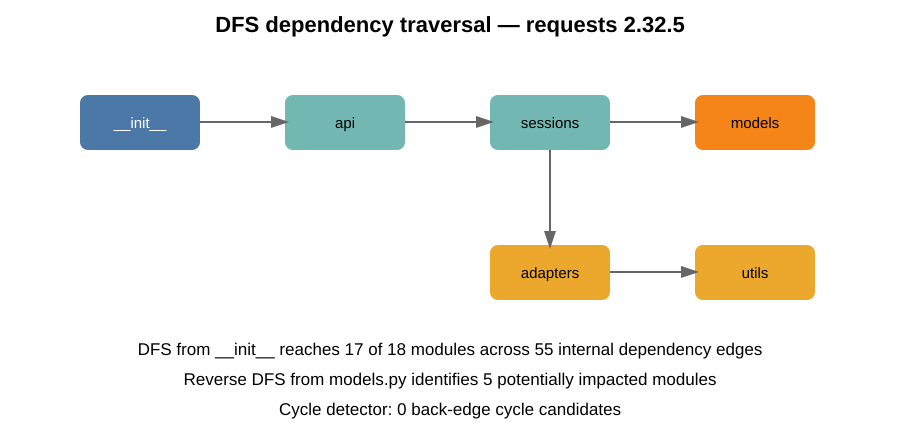

In [5]:
# Visualise internal dependency structure and highlight the reverse-DFS impact set.
pos=nx.spring_layout(DG,seed=7)
plt.figure(figsize=(13,9))
nx.draw_networkx_edges(DG,pos,alpha=.25,arrows=True)
nx.draw_networkx_nodes(DG,pos,node_size=350)
nx.draw_networkx_labels(DG,pos,font_size=8)
plt.title("requests dependency graph — DFS impact analysis")
plt.axis("off"); plt.show()


In [6]:
starts=list(DG.nodes()); latencies=[]; counts=[]
for i in range(2000):
    s=starts[i%len(starts)]
    t0=time.perf_counter(); reached=dfs(DG,s)
    latencies.append((time.perf_counter()-t0)*1000); counts.append(len(reached))
print(f"2,000 DFS traversals median latency: {np.median(latencies):.5f} ms")
print(f"95th percentile latency: {np.percentile(latencies,95):.5f} ms")
print(f"Average reachable module count: {np.mean(counts):.2f}")


2,000 DFS traversals median latency: 0.00160 ms
95th percentile latency: 0.00972 ms
Average reachable module count: 6.00

## Interview-ready takeaway

DFS explores one branch deeply before backtracking and runs in **O(V + E)**. Here it becomes a practical dependency-intelligence primitive for reachability, change-impact analysis and cycle detection.

**CV bullet:** Built a DFS dependency explorer over the real `requests` codebase using AST parsing, directed graphs, reverse reachability, cycle detection, benchmarking and visualisation.
